## Install libraries and packages

In [19]:
#Install packages into kernel's enviornment
%pip install seaborn scikit-learn
%pip install -e '../../decipher-bc'


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Obtaining file:///Users/alanxie/CodingProjects/Columbia/Azizi%20Lab/Spatial%20Nut%20Carcinoma/decipher-bc
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for scdecipher (pyproject.toml) ... done
  Created wheel for scdecipher: filename=scdecipher-0.1.3-py3-none-any.whl size=2193 sha256=a083d111b7757fd42c95b1c711ba62e2d1ae21b110921676f57fa3e48194b60f
  Stored in directory: /private/var/folders/3p/7nndjfj95j1b_fk0h38c9_y80000gn/T/pip-ephem-wheel-cache-bfucr7wf/wheels/ea/06/26/26159dbfb6aa8149e61b1400ecea7c99526e36bf7872679e1e
Successfully built scdecipher
  Attempting uninstall: scdecipher
    Found existing installation: scdecipher 0.

In [20]:
#Import libraries and packages
import os
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import logging
from scipy.stats import spearmanr

In [21]:
# Automatically reload the package if you edit the .py files
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
# Import the new package name
import decipher as dc
dc.pl.activate_journal_quality()

In [23]:
# Import batch correction models
sys.path.insert(0, '..')   # adds decipher-bc-methods/ to path

import importlib
avzx = importlib.import_module('attention-v-z-x')   # avzx.tl.decipher_train(...)

## Load simulated data

Directly loads `0626_vz_0.10_0.20_0.30_0.40.h5ad` — a v-to-z shifted dataset with 5 batches.

Batch shifts applied to `z` (not `v`):
- batch `0.00`: shift = 0.0 (unshifted baseline)
- batch `0.10`: shift = 0.10
- batch `0.20`: shift = 0.20
- batch `0.30`: shift = 0.30
- batch `0.40`: shift = 0.40

In [24]:
H5AD_PATH = "../Data/Simulated Data/Simulated Adata/v-to-z/0626_vz_0.10_0.20_0.30_0.40.h5ad"

adata = ad.read_h5ad(H5AD_PATH)
adata.obs_names_make_unique()

print(adata)
print("batch unique values:", adata.obs["batch"].unique().tolist())
print("shift_type unique values:", adata.obs["shift_type"].unique().tolist())

AnnData object with n_obs × n_vars = 2500 × 50
    obs: 'latent_t', 'shift', 'shift_type', 'batch'
    layers: 'counts'
batch unique values: ['0.00', '0.10', '0.20', '0.30', '0.40']
shift_type unique values: ['none', 'vz']


## Run native decipher on simulated data

Epoch 68 (batch 35/35) | | train elbo: 32.43 (last epoch: 32.63) | val ll: 41.09:   7%|▋         | 68/1000 [00:11<02:34,  6.03it/s]2026-06-26 15:54:35,249 | INFO : Early stopping has been triggered.
2026-06-26 15:54:35,250 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-26 15:54:35,250 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-06-26 15:54:35,250 | INFO : Saving decipher model with run_id 2026-06-26-15-54-35-connected-weary-sauce.


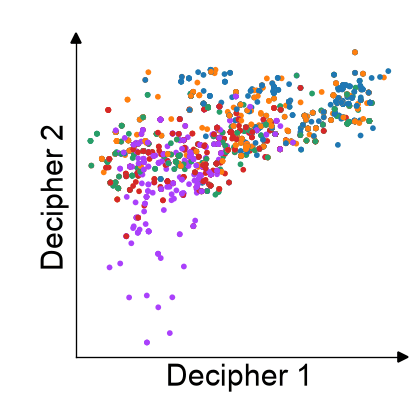

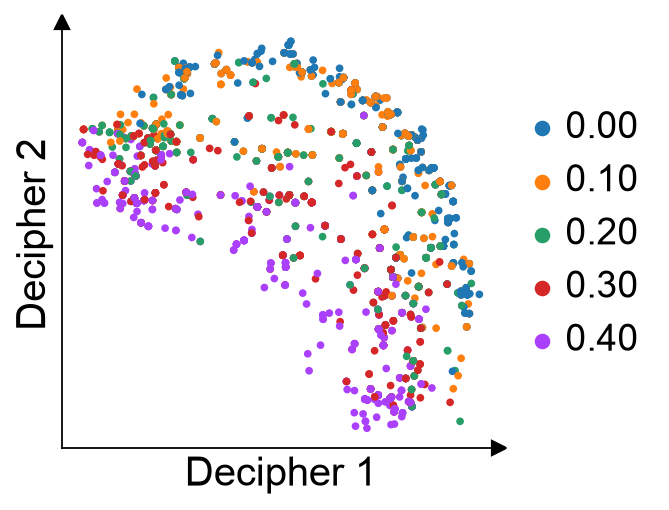

In [25]:
from decipher.tools._decipher import DecipherConfig
decipher_config = DecipherConfig(learning_rate=1e-3, seed=1)

adata_native = adata.copy()
d_native, val_native = dc.tl.decipher_train(
    adata_native, decipher_config, plot_kwargs={"color": "batch"},
    plot_every_k_epochs=5,
)

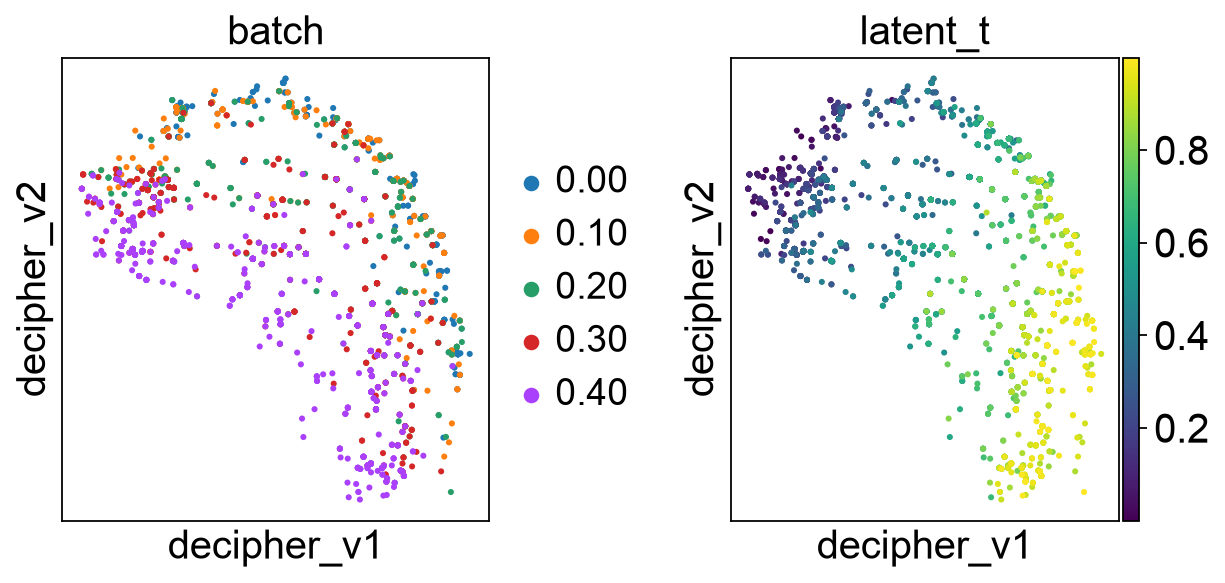

In [26]:
# Plot decipher_v colored by batch and latent_t
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(4*2, 4))
sc.pl.embedding(adata_native, basis="decipher_v", color="batch",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(adata_native, basis="decipher_v", color="latent_t",
                show=False, ax=axes[1], size=30)
plt.tight_layout()
plt.show()

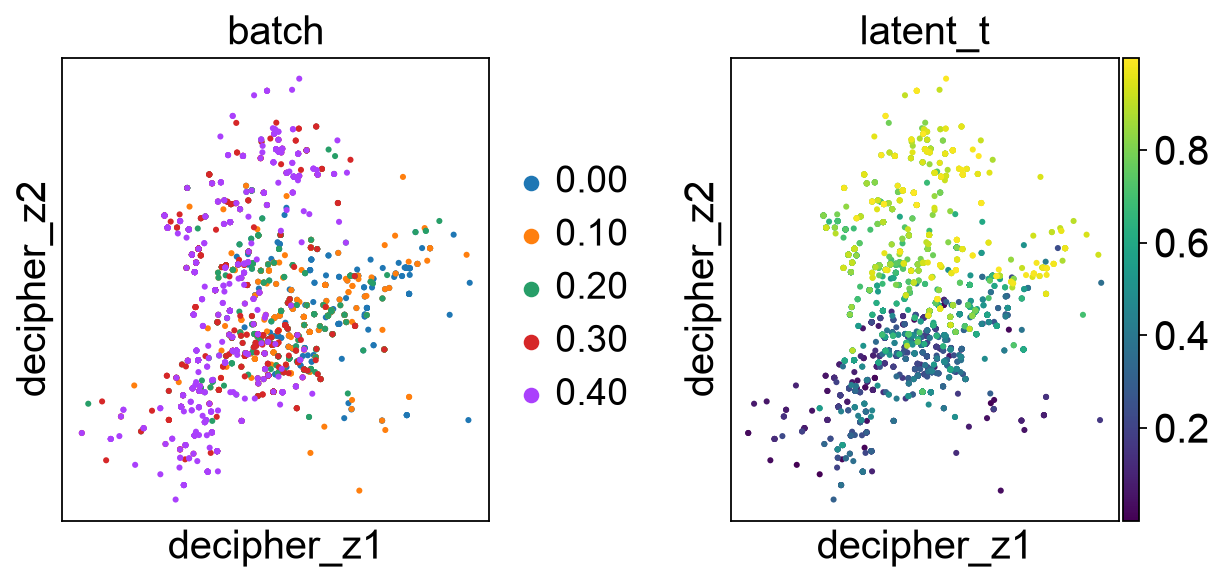

In [27]:
# decipher_z: no batch correction — baseline showing batch is still visible in z.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(4*2, 4))
sc.pl.embedding(adata_native, basis="decipher_z", color="batch",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(adata_native, basis="decipher_z", color="latent_t",
                show=False, ax=axes[1], size=30)
plt.tight_layout()
plt.show()

In [28]:
# Spearman correlation: decipher_v[:,0] vs latent_t per batch
v_native = adata_native.obsm["decipher_v"]

print("── Spearman correlation: decipher_v vs latent_t (per batch) ──────────")
for b in sorted(adata_native.obs["batch"].unique()):
    mask = adata_native.obs["batch"] == b
    rho, pval = spearmanr(v_native[mask, 0], adata_native.obs["latent_t"][mask])
    print(f"  batch={b:<6}  rho={rho:+.4f}  p={pval:.2e}")

── Spearman correlation: decipher_v vs latent_t (per batch) ──────────
  batch=0.00    rho=+0.9366  p=7.01e-229
  batch=0.10    rho=+0.9224  p=6.76e-208
  batch=0.20    rho=+0.9170  p=5.70e-201
  batch=0.30    rho=+0.9291  p=2.73e-217
  batch=0.40    rho=+0.9188  p=3.91e-203


In [29]:
from sklearn.metrics import silhouette_score

v = adata_native.obsm["decipher_v"].copy()
labels = adata_native.obs["batch"].astype(str)

print("── Silhouette score in v-space (higher = stronger batch separation) ─────")
score = silhouette_score(v, labels, sample_size=5000, random_state=42)
print(f"  batch  silhouette = {score:.4f}")

── Silhouette score in v-space (higher = stronger batch separation) ─────
  batch  silhouette = -0.0321


## Run attention-v-z-x on simulated data

Epoch 890 (batch 35/35) | | train elbo: 28.56 (last epoch: 28.45) | val ll: 39.53:  89%|████████▉ | 890/1000 [02:26<00:18,  6.06it/s]2026-06-26 15:57:02,647 | INFO : Early stopping has been triggered.
2026-06-26 15:57:02,649 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-26 15:57:02,649 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-06-26 15:57:02,649 | INFO : Saving decipher model with run_id 2026-06-26-15-57-02-swarm-black-edge.


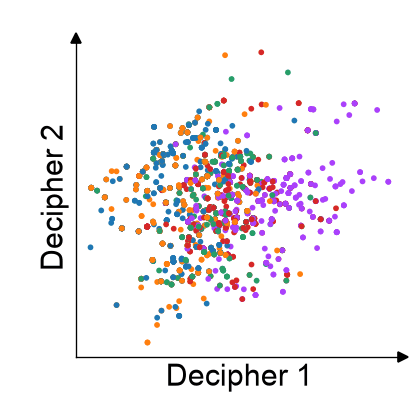

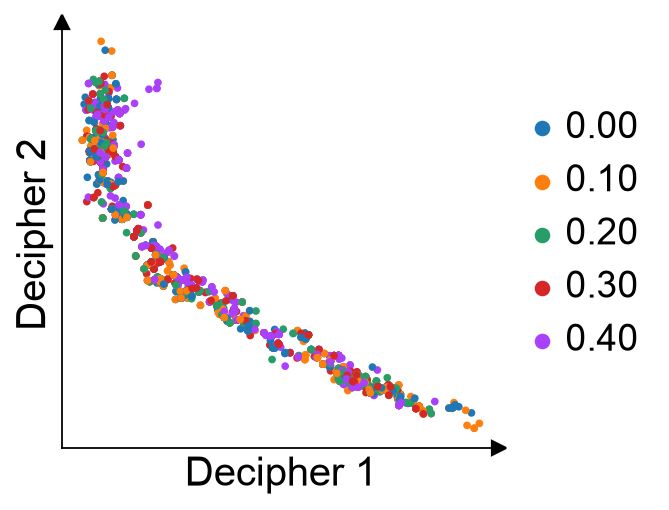

In [30]:
from decipher.tools._decipher import DecipherConfig
decipher_config = DecipherConfig(learning_rate=1e-4, seed=1, early_stopping_patience=50)

adata_avzx = adata.copy()
d_avzx, val_avzx = avzx.tl.decipher_train(
    adata_avzx, decipher_config, plot_kwargs={"color": "batch"},
    batch_key="batch",
    plot_every_k_epochs=5,
)

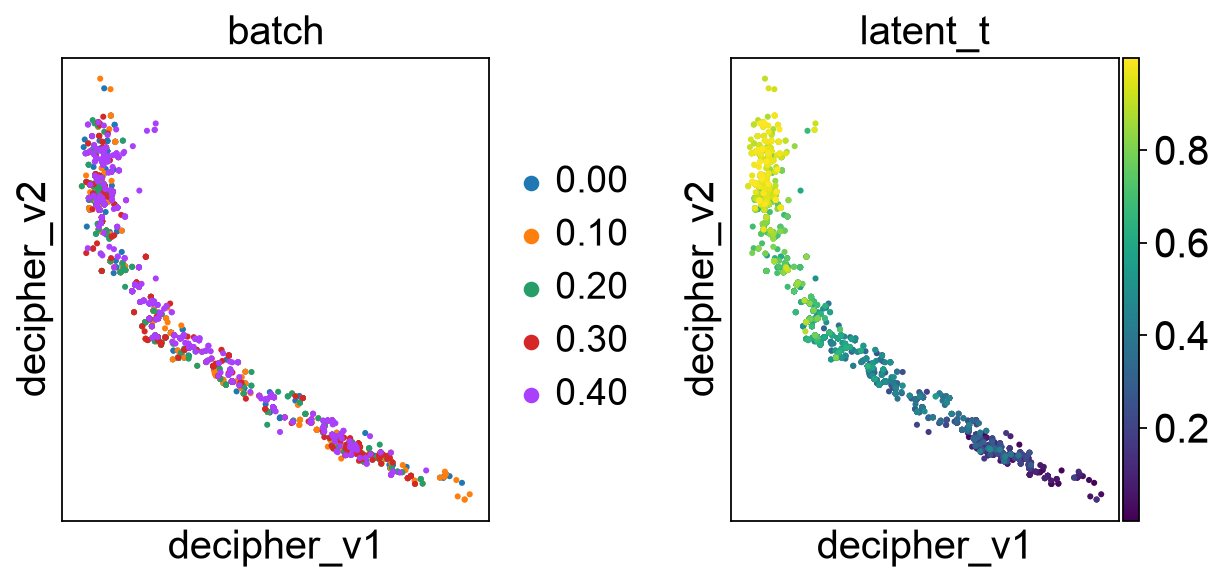

In [31]:
# Plot decipher_v — batch groups should still be visible here (v captures biology + batch)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(4*2, 4))
sc.pl.embedding(adata_avzx, basis="decipher_v", color="batch",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(adata_avzx, basis="decipher_v", color="latent_t",
                show=False, ax=axes[1], size=30)
plt.tight_layout()
plt.show()

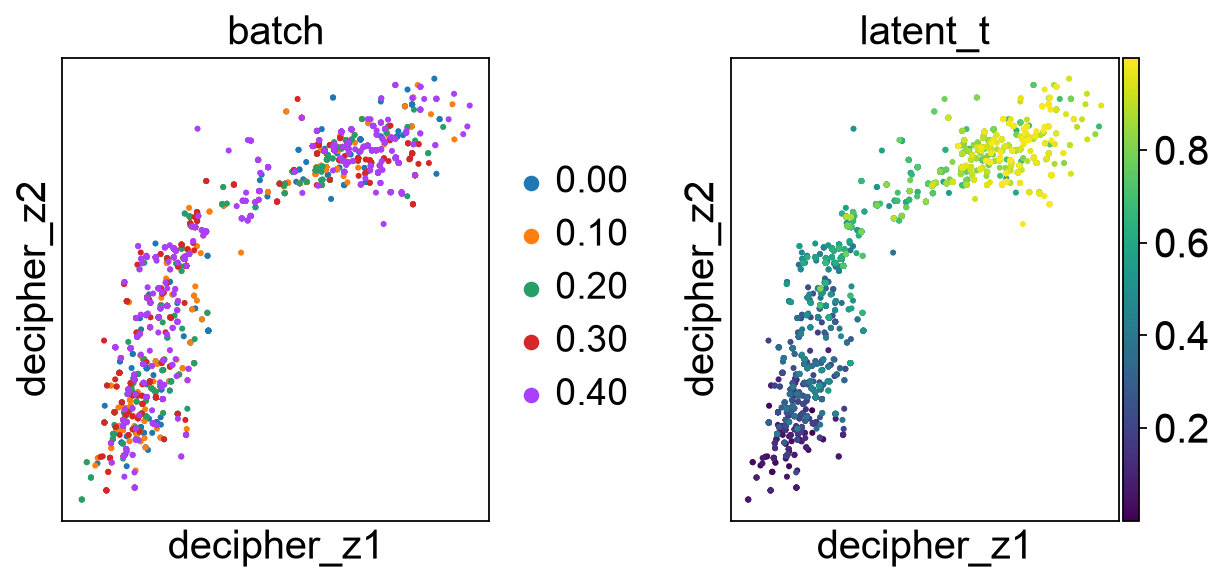

In [32]:
# Plot decipher_z — this is where attention-v-z-x applies batch correction.
# Batch groups should be less separated here if the model is working.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(4*2, 4))
sc.pl.embedding(adata_avzx, basis="decipher_z", color="batch",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(adata_avzx, basis="decipher_z", color="latent_t",
                show=False, ax=axes[1], size=30)
plt.tight_layout()
plt.show()

In [33]:
# Spearman correlation: does avzx recover latent_t better than native decipher?
v_avzx = adata_avzx.obsm["decipher_v"]

print("── Spearman correlation: decipher_v vs latent_t (per batch) ──────────")
for b in sorted(adata_avzx.obs["batch"].unique()):
    mask = adata_avzx.obs["batch"] == b
    rho, pval = spearmanr(v_avzx[mask, 0], adata_avzx.obs["latent_t"][mask])
    print(f"  batch={b:<6}  rho={rho:+.4f}  p={pval:.2e}")

── Spearman correlation: decipher_v vs latent_t (per batch) ──────────
  batch=0.00    rho=-0.9131  p=4.17e-196
  batch=0.10    rho=-0.9207  p=1.31e-205
  batch=0.20    rho=-0.9089  p=2.48e-191
  batch=0.30    rho=-0.9031  p=5.42e-185
  batch=0.40    rho=-0.9013  p=4.83e-183


In [34]:
from sklearn.metrics import silhouette_score

v = adata_avzx.obsm["decipher_v"].copy()
labels = adata_avzx.obs["batch"].astype(str)

print("── Silhouette score in v-space (lower = better batch correction) ────────")
score = silhouette_score(v, labels, sample_size=5000, random_state=42)
print(f"  batch  silhouette = {score:.4f}")

── Silhouette score in v-space (lower = better batch correction) ────────
  batch  silhouette = -0.0439


## Ground-truth Z-space sanity check

Reconstructs the true latent Z from the simulation parameters (before any model is run).

**Expected:** V mixed across batches, Z clearly separated by batch — this confirms the simulated data is set up correctly before evaluating any model.

In [35]:
# Reconstruct ground-truth latent_z from simulation parameters.
# The 0626 file was generated by simulate_simple2 with:
#   shift_type="vz", shifts=[0.1, 0.2, 0.3, 0.4], mag=1.0, sigma=0.1, seed=0
#   baseline: cell_seed=0, shifted batches: cell_seed=1,2,3,4
SEED   = 0
SIGMA  = 0.1
SHIFTS = [0.0, 0.1, 0.2, 0.3, 0.4]  # baseline + 4 shifted batches

gt_z_list     = []
gt_t_list     = []
gt_batch_list = []

for i, shift in enumerate(SHIFTS):
    cell_seed = SEED if shift == 0.0 else SEED + i
    rng = np.random.default_rng(cell_seed)

    latent_t = rng.uniform(0, 1, size=(500, 1))

    # simulate_simple2: z is 2D; dim0 = biology, dim1 = batch direction
    z_mean = np.concatenate([latent_t, np.zeros_like(latent_t)], axis=1)
    if shift > 0.0:
        z_mean[:, 1] += shift
    latent_z = rng.normal(z_mean, SIGMA)

    gt_z_list.append(latent_z)
    gt_t_list.append(latent_t[:, 0])
    gt_batch_list.extend([f"{shift:.2f}"] * 500)

gt_z     = np.vstack(gt_z_list)   # (2500, 2)
gt_t     = np.concatenate(gt_t_list)
gt_batch = np.array(gt_batch_list)

# Wrap in AnnData for sc.pl.embedding
adata_gt = ad.AnnData(X=gt_z)
adata_gt.obsm["latent_z"] = gt_z
adata_gt.obs["batch"]     = gt_batch
adata_gt.obs["latent_t"]  = gt_t

print("Ground-truth latent_z shape:", gt_z.shape)
print("batch unique:", np.unique(gt_batch).tolist())

Ground-truth latent_z shape: (2500, 2)
batch unique: ['0.00', '0.10', '0.20', '0.30', '0.40']


... storing 'batch' as categorical


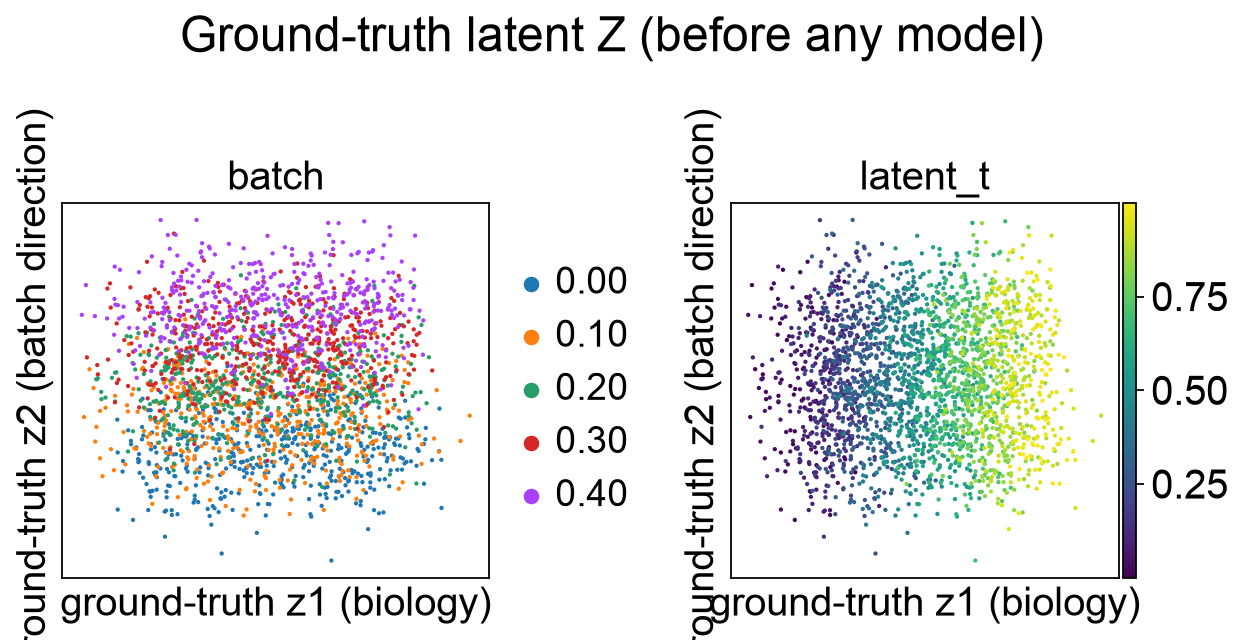

In [36]:
# Plot ground-truth Z directly (no UMAP — already 2D)
# dim0 = biological (driven by latent_t), dim1 = batch shift direction
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(4*2, 4))
for ax, color in zip(axes, ["batch", "latent_t"]):
    sc.pl.embedding(adata_gt, basis="latent_z", color=color,
                    show=False, ax=ax, size=15)
    ax.set_xlabel("ground-truth z1 (biology)")
    ax.set_ylabel("ground-truth z2 (batch direction)")
plt.suptitle("Ground-truth latent Z (before any model)", y=1.02)
plt.tight_layout()
plt.show()

## Parameter sweep: shift magnitude vs sigma

The original sigma=0.1 is too large relative to the shifts (0.1–0.4), causing batches to overlap in Z.
This cell sweeps over candidate (sigma, shifts) combos so you can visually pick a working configuration
before regenerating the h5ad.

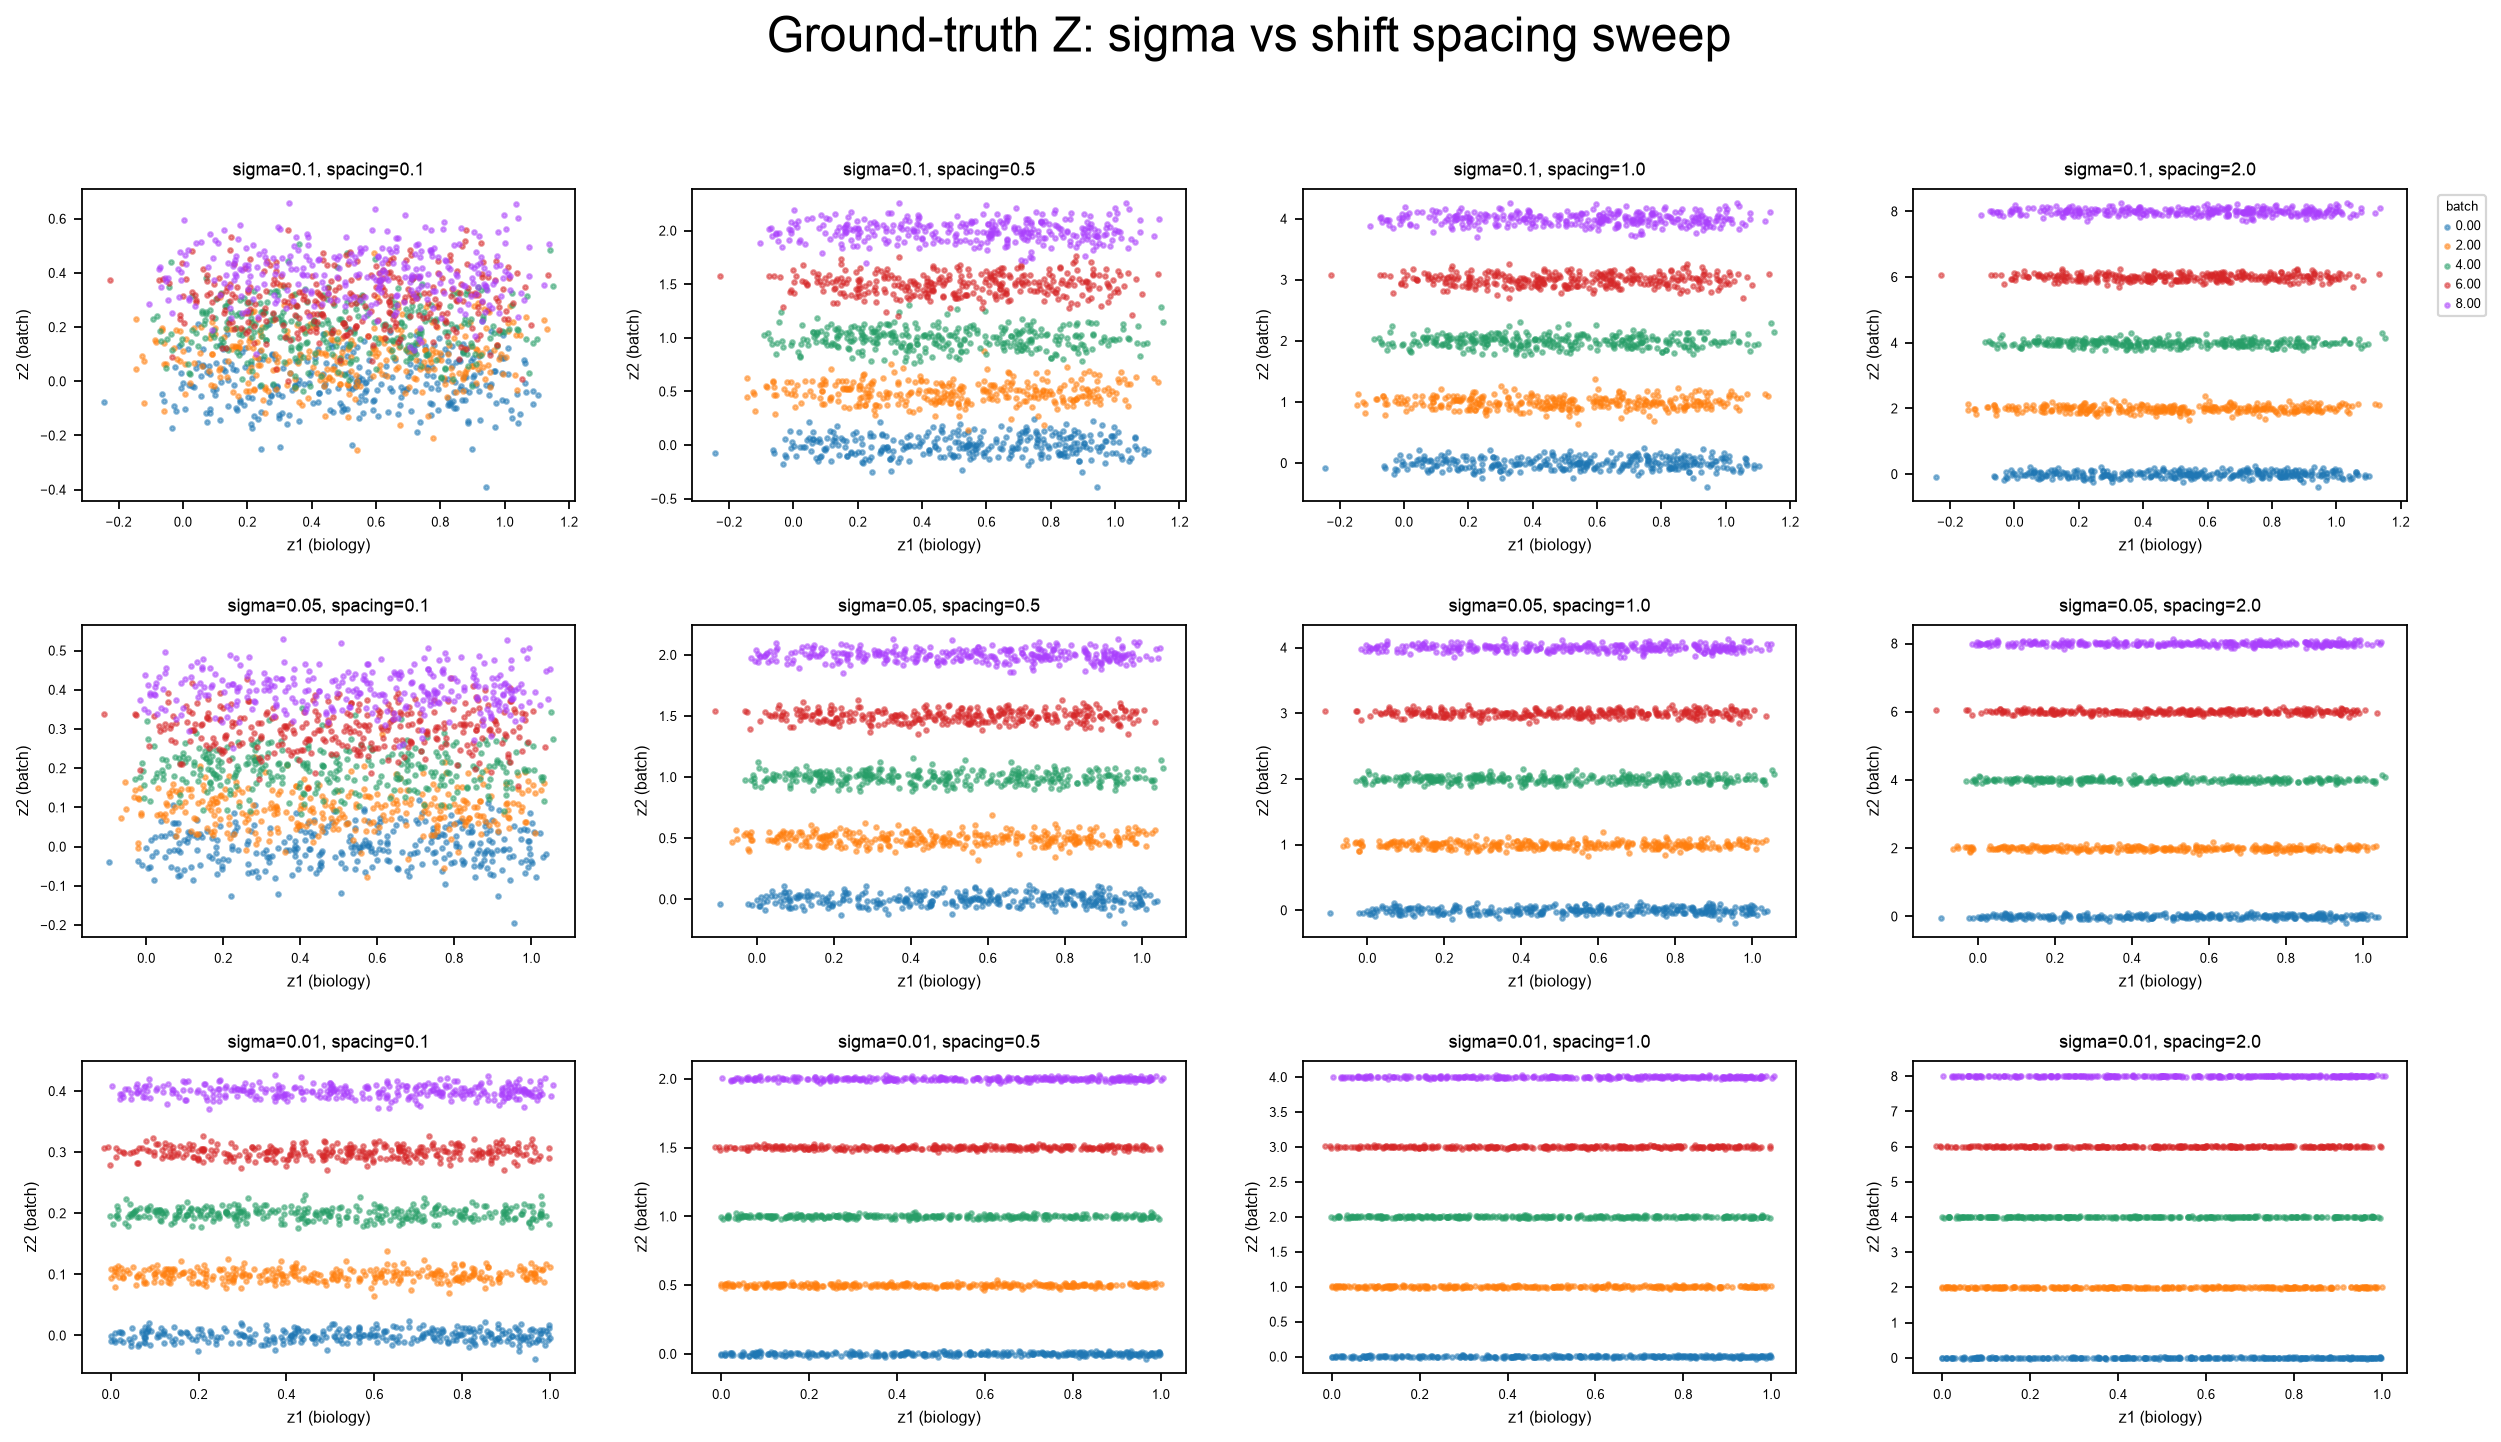

In [37]:
# Each row = one sigma value; each column = one shift spacing
# The shift spacing controls the gap between adjacent batches in z2.
# Batches are always [0.0, 1x, 2x, 3x, 4x] * spacing.

SIGMAS   = [0.1, 0.05, 0.01]          # decreasing noise
SPACINGS = [0.1, 0.5, 1.0, 2.0]       # increasing shift gap between batches

fig, axes = plt.subplots(
    nrows=len(SIGMAS), ncols=len(SPACINGS),
    figsize=(4 * len(SPACINGS), 3 * len(SIGMAS))
)

SEED = 0
N    = 300  # fewer points for speed

for row, sigma in enumerate(SIGMAS):
    for col, spacing in enumerate(SPACINGS):
        shifts = [spacing * k for k in range(5)]
        z_list, batch_list = [], []

        for i, shift in enumerate(shifts):
            cell_seed = SEED if shift == 0.0 else SEED + i
            rng = np.random.default_rng(cell_seed)
            latent_t = rng.uniform(0, 1, size=(N, 1))
            z_mean = np.concatenate([latent_t, np.zeros_like(latent_t)], axis=1)
            if shift > 0.0:
                z_mean[:, 1] += shift
            latent_z = rng.normal(z_mean, sigma)
            z_list.append(latent_z)
            batch_list.extend([f"{shift:.2f}"] * N)

        z_all = np.vstack(z_list)
        b_all = np.array(batch_list)

        ax = axes[row, col]
        for b in np.unique(b_all):
            mask = b_all == b
            ax.scatter(z_all[mask, 0], z_all[mask, 1], s=4, alpha=0.5, label=b)
        ax.set_title(f"sigma={sigma}, spacing={spacing}", fontsize=8)
        ax.set_xlabel("z1 (biology)", fontsize=7)
        ax.set_ylabel("z2 (batch)", fontsize=7)
        ax.tick_params(labelsize=6)

axes[0, -1].legend(title="batch", fontsize=6, title_fontsize=6, bbox_to_anchor=(1.05, 1))
plt.suptitle("Ground-truth Z: sigma vs shift spacing sweep", y=1.01)
plt.tight_layout()
plt.show()